# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [2]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
# !pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [5]:
# TODO: extract the dataset zip to an output folder
ZIP_PATH = 'Heart Disease Prediction Dataset.zip'  # or your path
EXTRACT_DIR = 'heart_ds'
# Hint: use zipfile.ZipFile(ZIP_PATH).extractall(EXTRACT_DIR)

# TODO: list CSV files under EXTRACT_DIR
csv_path = "dataset_heart.csv"

# TODO: load the CSV into a DataFrame named df
df = pd.read_csv(csv_path)

# TODO: inspect df
display(df)

# TODO: identify target column
target = df['heart disease']  # 'target'

# TODO: split features and target
X = df.drop(columns=['heart disease'])  # df.drop(columns=[...])
y = target  # df[...]

# TODO: train test split with stratification
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state= 42, stratify=y )
# Hint: train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)


,age,sex,chest pain type,resting blood pressure,serum cholestoral,fasting blood sugar,resting electrocardiographic results,max heart rate,exercise induced angina,oldpeak,ST segment,major vessels,thal,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,2
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,1
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,2
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,1
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,1
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,1
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,1
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,1


### Basic visual checks

In [6]:
df.dtypes

,0
age,int64
sex,int64
chest pain type,int64
resting blood pressure,int64
serum cholestoral,int64
fasting blood sugar,int64
resting electrocardiographic results,int64
max heart rate,int64
exercise induced angina,int64
oldpeak,float64


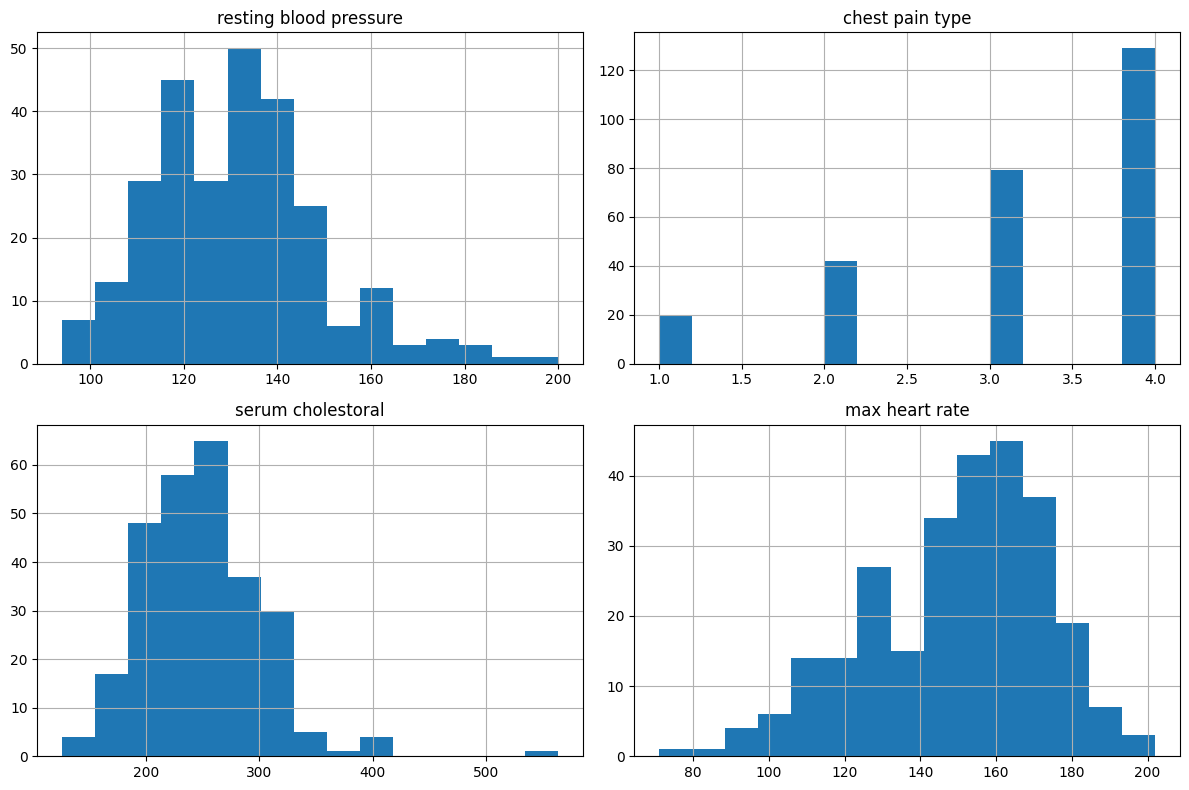

/tmp/ipykernel_18743/108923460.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='heart disease', data=df, palette='viridis')


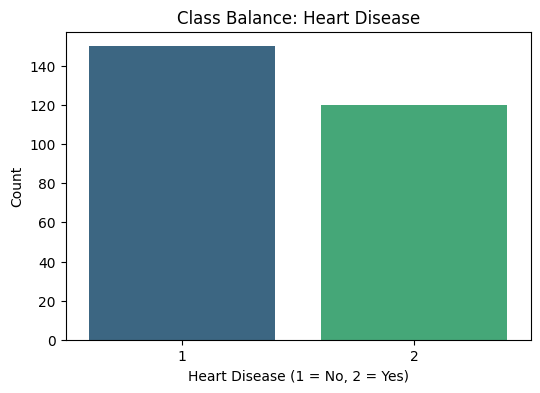

In [7]:
import seaborn as sns

# TODO: pick a few numeric columns and plot histograms
num_cols_selected = ["resting blood pressure", "chest pain type", "serum cholestoral", "max heart rate"]
df[num_cols_selected].hist(bins=15, figsize=(12, 8), layout=(2, 2))
plt.tight_layout()
plt.show()

# TODO: plot class balance as a bar chart
plt.figure(figsize=(6, 4))
sns.countplot(x='heart disease', data=df, palette='viridis')
plt.title('Class Balance: Heart Disease')
plt.xlabel('Heart Disease (1 = No, 2 = Yes)')
plt.ylabel('Count')
plt.show()

## Preprocessing pipeline

In [8]:
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()  # list of object, category, or bool columns
num_cols = X.select_dtypes(include=["int64","float"]).columns.tolist()  # list of numeric columns

# TODO: build a ColumnTransformer named pre
pre = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

## Helper - evaluation function

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

def eval_and_report(name, model, X_test, y_test):
    """Compute metrics and draw confusion matrix and ROC if available.
    """
    # TODO: predictions
    y_pred = model.predict(X_test)

    # TODO: compute metrics dict with accuracy, precision, recall, f1
    # Note: Using pos_label=2 because according to your plots,
    # 'heart disease' 1 is 'No' and 2 is 'Yes'.
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, pos_label=2),
        'recall': recall_score(y_test, y_pred, pos_label=2),
        'f1': f1_score(y_test, y_pred, pos_label=2),
    }

    print(f"--- {name} ---")
    for metric, value in metrics.items():
        print(f"{metric.capitalize()}: {value:.4f}")

    # TODO: confusion matrix plot
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0], cmap='Blues')
    ax[0].set_title(f'Confusion Matrix: {name}')

    # TODO: ROC curve if model has predict_proba
    if hasattr(model, "predict_proba"):
        RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax[1])
        ax[1].set_title(f'ROC Curve: {name}')
    else:
        ax[1].text(0.5, 0.5, 'ROC not available (no predict_proba)',
                   ha='center', va='center')

    plt.tight_layout()
    plt.show()

    return metrics

## Exercise 2 - Logistic Regression without Grid Search

--- Logistic Regression (No GS) ---
Accuracy: 0.8519
Precision: 0.7857
Recall: 0.9167
F1: 0.8462


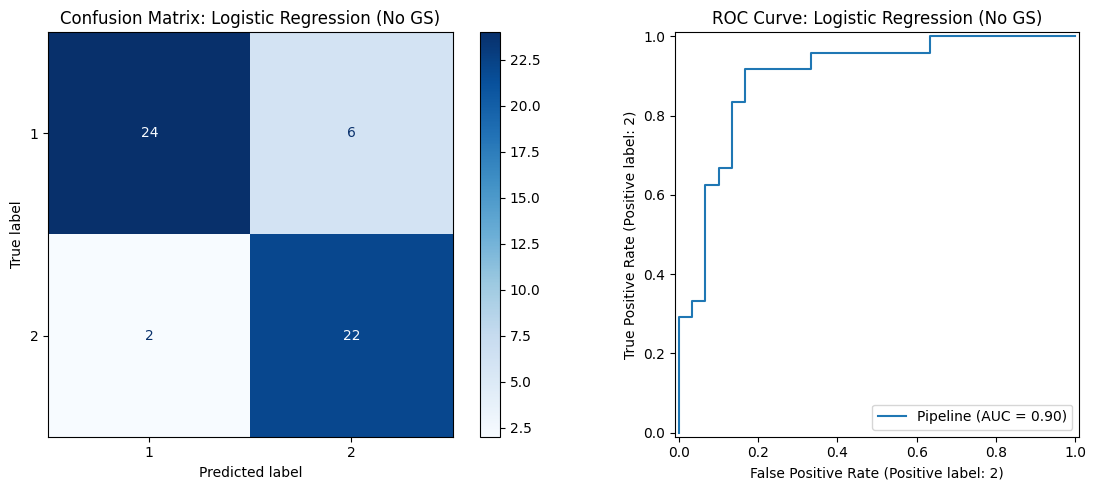

In [10]:
# TODO: create a Pipeline with your preprocessor and LogisticRegression
pipe_lr = Pipeline(steps=[
    ('preprocessor', pre),
    ('lr', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
])

# TODO: fit on training data
pipe_lr.fit(X_train, y_train)

# TODO: evaluate with eval_and_report
lr_no_gs_metrics = eval_and_report('Logistic Regression (No GS)', pipe_lr, X_test, y_test)

## Exercise 3 - Logistic Regression with Grid Search

Best params: {'lr__C': 0.001, 'lr__penalty': 'l2'}
--- Logistic Regression (Grid Search) ---
Accuracy: 0.8148
Precision: 0.7692
Recall: 0.8333
F1: 0.8000


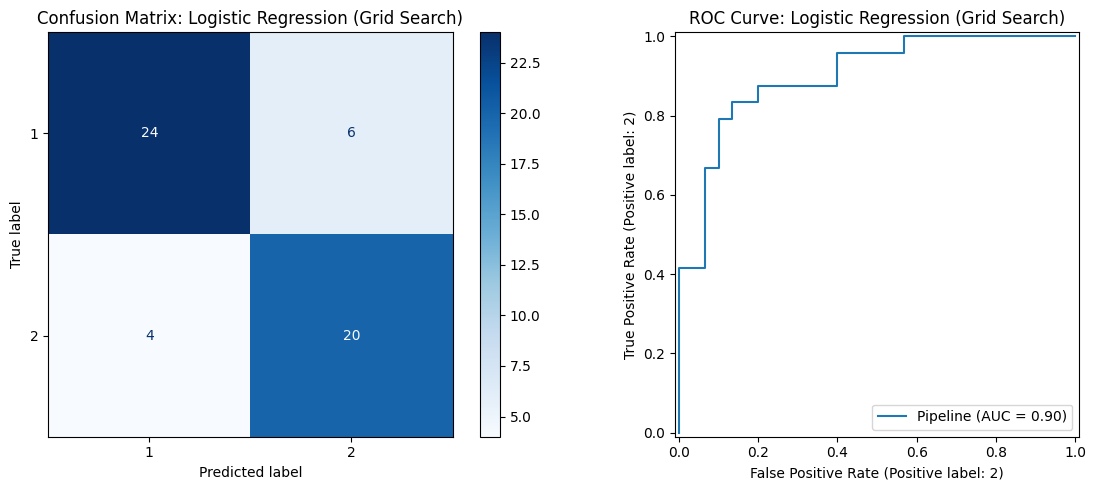

In [11]:
# TODO: build a Pipeline same as above
pipe_lr_cv = Pipeline(steps=[
    ('preprocessor', pre),
    ('lr', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
])

# TODO: define param_grid for lr__C and lr__penalty
# Hint: use small to large C values. 'liblinear' supports 'l1' and 'l2'.
param_grid = {
    'lr__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2']
}

# TODO: GridSearchCV with cv=5 and scoring='f1'
grid_lr = GridSearchCV(pipe_lr_cv, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train, y_train)

print('Best params:', grid_lr.best_params_)
best_lr = grid_lr.best_estimator_
lr_gs_metrics = eval_and_report('Logistic Regression (Grid Search)', best_lr, X_test, y_test)

## Exercise 4 - SVM without Grid Search

--- SVM (No GS) ---
Accuracy: 0.8148
Precision: 0.7692
Recall: 0.8333
F1: 0.8000


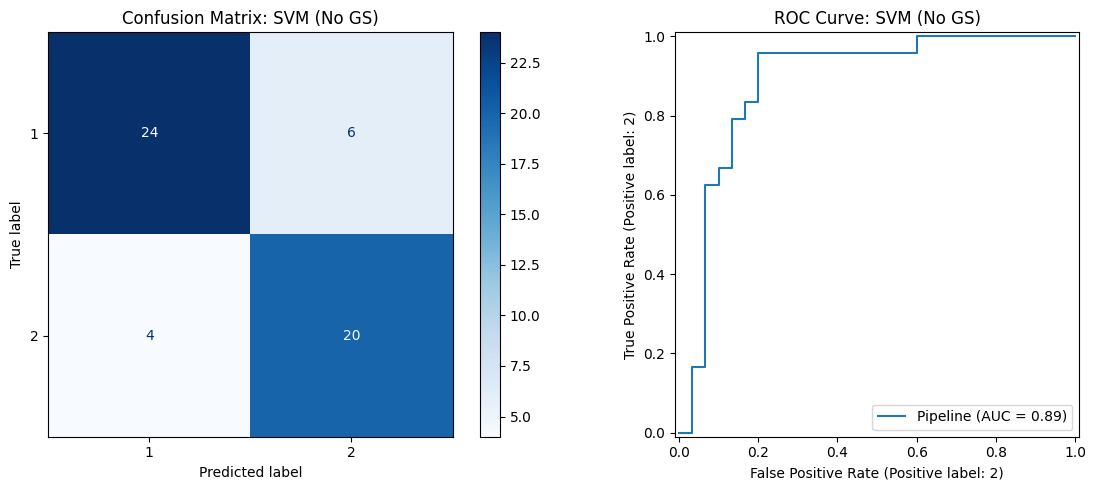

In [12]:
# TODO: choose kernel and hyperparameters for SVC
# Hint: try kernel='rbf' with C=1.0 and gamma='scale'
pipe_svm = Pipeline(steps=[
    ('preprocessor', pre),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE))
])

# TODO: fit on training data
pipe_svm.fit(X_train, y_train)

# TODO: evaluate with eval_and_report
svm_no_metrics = eval_and_report('SVM (No GS)', pipe_svm, X_test, y_test)

## Exercise 5 - SVM with Grid Search

Best params: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
--- SVM (Grid Search) ---
Accuracy: 0.8519
Precision: 0.8077
Recall: 0.8750
F1: 0.8400


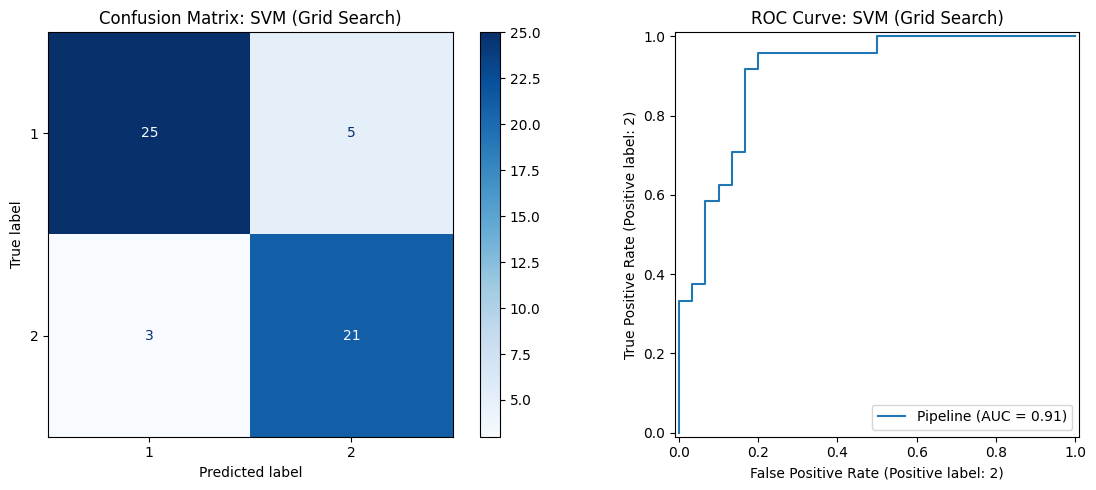

In [13]:
# TODO: Pipeline with SVC(probability=True) so you can plot ROC
pipe_svm_cv = Pipeline(steps=[
    ('preprocessor', pre),
    ('svm', SVC(probability=True, random_state=RANDOM_STATE))
])

# TODO: param_grid with svm__kernel, svm__C, svm__gamma
svm_param_grid = {
    'svm__kernel': ['rbf', 'linear'],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 'auto']
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_svm = GridSearchCV(pipe_svm_cv, svm_param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_svm.fit(X_train, y_train)

print('Best params:', grid_svm.best_params_)
best_svm = grid_svm.best_estimator_
svm_gs_metrics = eval_and_report('SVM (Grid Search)', best_svm, X_test, y_test)

## Exercise 6 - XGBoost without Grid Search

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:31:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost (No GS) ---
Accuracy: 0.7963
Precision: 0.7407
Recall: 0.8333
F1: 0.7843


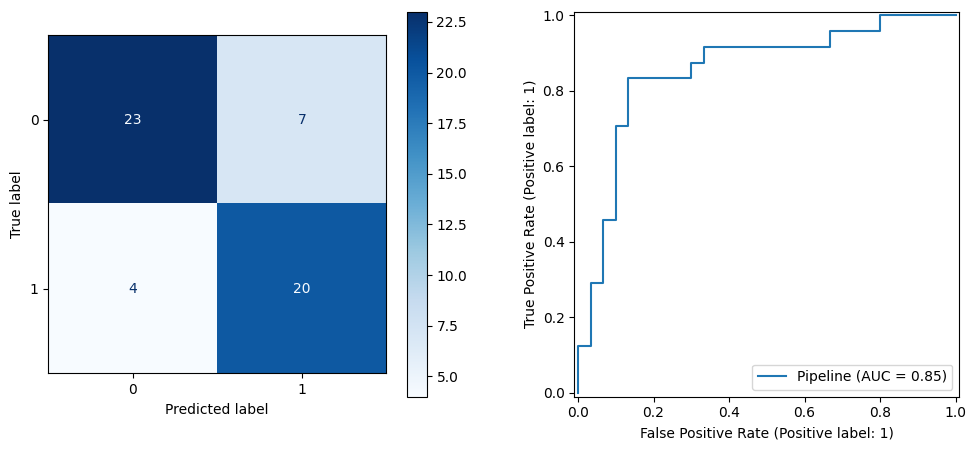

In [14]:
# TODO: build an XGBClassifier and wrap it in a Pipeline with pre
# XGBoost typically expects classes starting from 0, but our target is 1 and 2.
# The evaluation function and pipeline should handle this, but some versions prefer [0, 1].
# For now, we'll keep the current target and see if XGBClassifier handles it.
pipe_xgb = Pipeline(steps=[
    ('preprocessor', pre),
    ('xgb', XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=3, use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE))
])

# Adjusting y_train/y_test temporarily for XGBoost if it expects 0/1 instead of 1/2
# (1 becomes 0, 2 becomes 1)
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

# TODO: fit on training data
pipe_xgb.fit(X_train, y_train_xgb)

# TODO: evaluate with eval_and_report
# We need to use pos_label=1 for metrics since we shifted labels
def eval_and_report_xgb(name, model, X_test, y_test_shifted):
    y_pred = model.predict(X_test)
    metrics = {
        'accuracy': accuracy_score(y_test_shifted, y_pred),
        'precision': precision_score(y_test_shifted, y_pred),
        'recall': recall_score(y_test_shifted, y_pred),
        'f1': f1_score(y_test_shifted, y_pred),
    }
    print(f"--- {name} ---")
    for metric, value in metrics.items():
        print(f"{metric.capitalize()}: {value:.4f}")

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ConfusionMatrixDisplay.from_predictions(y_test_shifted, y_pred, ax=ax[0], cmap='Blues')
    RocCurveDisplay.from_estimator(model, X_test, y_test_shifted, ax=ax[1])
    plt.show()
    return metrics

xgb_no_metrics = eval_and_report_xgb('XGBoost (No GS)', pipe_xgb, X_test, y_test_xgb)

## Exercise 7 - XGBoost with Grid Search

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:32:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 300, 'xgb__subsample': 1.0}
--- XGBoost (Grid Search) ---
Accuracy: 0.7963
Precision: 0.7407
Recall: 0.8333
F1: 0.7843


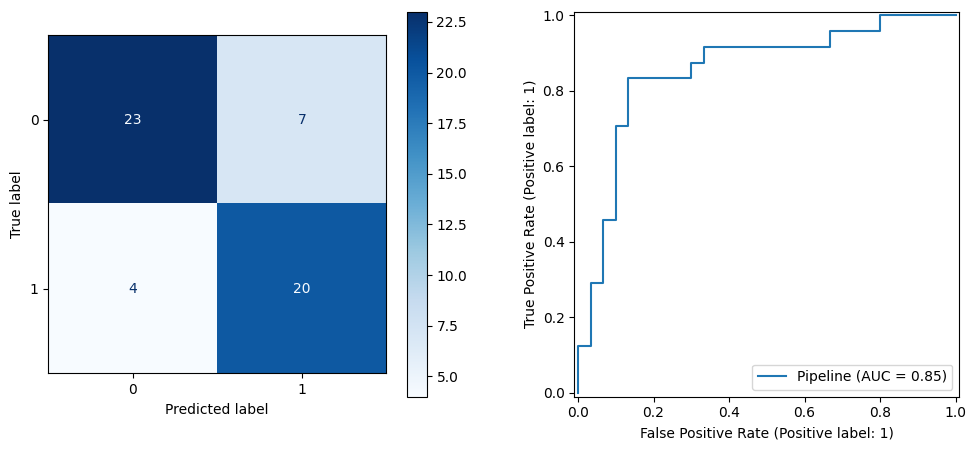

In [15]:
# Exercise 7 - XGBoost with Grid Search
# TODO: Pipeline with XGBClassifier
pipe_xgb_cv = Pipeline(steps=[
    ('preprocessor', pre),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE))
])

# TODO: define a reasonable param_grid
xgb_param_grid = {
    'xgb__n_estimators': [100, 300],
    'xgb__learning_rate': [0.01, 0.1],
    'xgb__max_depth': [3, 5],
    'xgb__subsample': [0.8, 1.0]
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_xgb = GridSearchCV(pipe_xgb_cv, xgb_param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_xgb.fit(X_train, y_train_xgb)

print('Best params:', grid_xgb.best_params_)
best_xgb = grid_xgb.best_estimator_
xgb_gs_metrics = eval_and_report_xgb('XGBoost (Grid Search)', best_xgb, X_test, y_test_xgb)

## Compare models

In [16]:
# TODO: build a comparison DataFrame from your metrics dicts
summary = {
    'Logistic Regression (No GS)': lr_no_gs_metrics,
    'Logistic Regression (Grid Search)': lr_gs_metrics,
    'SVM (No GS)': svm_no_metrics,
    'SVM (Grid Search)': svm_gs_metrics,
    'XGBoost (No GS)': xgb_no_metrics,
    'XGBoost (Grid Search)': xgb_gs_metrics
}

comparison_df = pd.DataFrame.from_dict(summary, orient='index')
comparison_df.sort_values(by='f1', ascending=False)

,accuracy,precision,recall,f1
Logistic Regression (No GS),0.851852,0.785714,0.916667,0.846154
SVM (Grid Search),0.851852,0.807692,0.875000,0.840000
Logistic Regression (Grid Search),0.814815,0.769231,0.833333,0.800000
SVM (No GS),0.814815,0.769231,0.833333,0.800000
XGBoost (No GS),0.796296,0.740741,0.833333,0.784314
XGBoost (Grid Search),0.796296,0.740741,0.833333,0.784314
